In [1]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress INFO and WARNING messages
import tensorflow as tf

2025-05-03 22:27:41.634114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-03 22:27:41.648760: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-03 22:27:41.653181: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-03 22:27:41.664631: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
env = gym.make("CartPole-v1", render_mode="rgb_array")


In [3]:
model = DQN("MlpPolicy", env, verbose=0)
# Train the agent until performance is acceptable
TARGET_REWARD = 475
MAX_TIMESTEPS = 200_000
EVAL_FREQ = 10000
rewards_over_time = []

for i in range(0, MAX_TIMESTEPS, EVAL_FREQ):
    model.learn(total_timesteps=EVAL_FREQ, reset_num_timesteps=False, progress_bar=False)
    mean_reward, _ = evaluate_policy(model, model.get_env(), n_eval_episodes=10, render=True)
    rewards_over_time.append((i + EVAL_FREQ, mean_reward))
    print(f"Timestep {i + EVAL_FREQ}: Mean reward = {mean_reward}")
    if mean_reward >= TARGET_REWARD:
        print("Reached target performance!")
        break  #-------

Timestep 10000: Mean reward = 9.5
Timestep 20000: Mean reward = 9.3
Timestep 30000: Mean reward = 9.8
Timestep 40000: Mean reward = 90.3
Timestep 50000: Mean reward = 284.5
Timestep 60000: Mean reward = 233.0
Timestep 70000: Mean reward = 195.7
Timestep 80000: Mean reward = 173.6
Timestep 90000: Mean reward = 198.3
Timestep 100000: Mean reward = 175.8
Timestep 110000: Mean reward = 190.3
Timestep 120000: Mean reward = 171.7
Timestep 130000: Mean reward = 207.7
Timestep 140000: Mean reward = 178.6
Timestep 150000: Mean reward = 181.3
Timestep 160000: Mean reward = 183.9
Timestep 170000: Mean reward = 185.3
Timestep 180000: Mean reward = 184.8
Timestep 190000: Mean reward = 181.8
Timestep 200000: Mean reward = 189.4


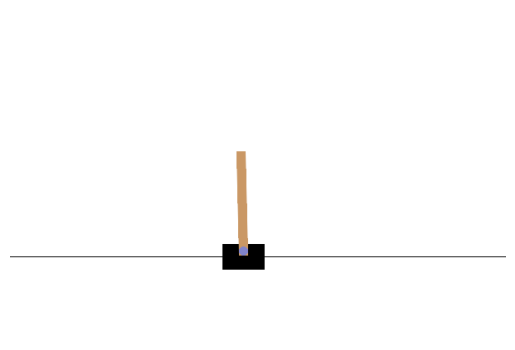

In [4]:
# Recreate environment with rgb_array for inline rendering
env = gym.make("CartPole-v1", render_mode="rgb_array")  #-------
obs, _ = env.reset()

for _ in range(300):
    frame = env.render()  #-------
    plt.imshow(frame)
    plt.axis('off')
    clear_output(wait=True)
    plt.show()
    time.sleep(0.03)  #-------

    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        obs, _ = env.reset()
env.close()

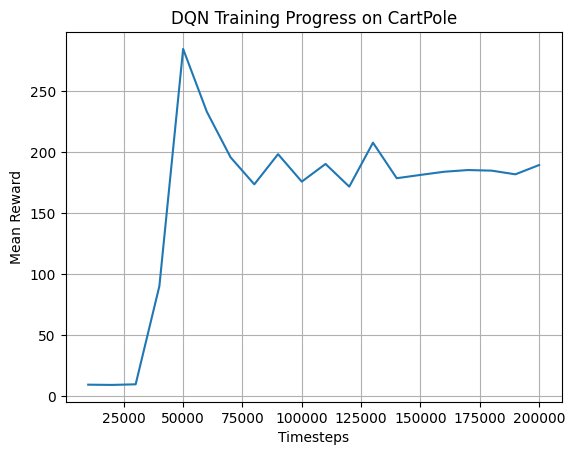

In [5]:
# Plot training rewards over time  #-------


timesteps, mean_rewards = zip(*rewards_over_time)  #-------
plt.plot(timesteps, mean_rewards)
plt.xlabel("Timesteps")
plt.ylabel("Mean Reward")
plt.title("DQN Training Progress on CartPole")
plt.grid(True)
plt.show()

In [6]:
# Save the trained model  #-------
model.save("dqn_cartpole_model")  #-------